In [ ]:

!pip -q install kagglehub pydicom

import os
import gc
import glob
import random
import zipfile
import shutil
import subprocess
import warnings
import re

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
import pydicom

from pydicom.pixels import apply_voi_lut

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

import kagglehub

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = 3
EPOCHS = 20

CLASS_NAMES = [
    "Adenocarcinoma",
    "Large Cell Carcinoma",
    "Squamous Cell Carcinoma"
]

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("Classes:", CLASS_NAMES)


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Classes: ['Adenocarcinoma', 'Large Cell Carcinoma', 'Squamous Cell Carcinoma']


In [ ]:
WORK_DIR = "/content/lung_cancer_project"
os.makedirs(WORK_DIR, exist_ok=True)

# ------------------------------------------------------------
# A) Kaggle CT-PET dataset
# ------------------------------------------------------------
print("=" * 70)
print("DOWNLOADING / LOCATING CT-PET DATASET")
print("=" * 70)

CTPET_PATH = kagglehub.dataset_download(
    "sshhwweettaa/lung-cancer-ct-pet-small-set-dicom-format"
)

print("CT-PET path:")
print(CTPET_PATH)

# ------------------------------------------------------------
# B) External Chest CT dataset
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("DOWNLOADING / LOCATING EXTERNAL CHEST CT DATASET")
print("=" * 70)

EXTERNAL_PATH = kagglehub.dataset_download(
    "mohamedhanyyy/chest-ctscan-images"
)

print("External Chest CT path:")
print(EXTERNAL_PATH)

print("\n" + "=" * 70)
print("LOCATING FIGSHARE ZIP")
print("=" * 70)

# Look for ZIP files uploaded directly into /content.
content_zip_candidates = sorted(
    glob.glob("/content/*.zip")
)

if not content_zip_candidates:
    content_zip_candidates = sorted(
        glob.glob("/content/*/*.zip")
    )

# Prefer a filename containing "lung" or "cancer".
preferred = [
    p for p in content_zip_candidates
    if "lung" in os.path.basename(p).lower()
    or "cancer" in os.path.basename(p).lower()
]

if preferred:
    FIGSHARE_ZIP = preferred[0]
elif content_zip_candidates:
    FIGSHARE_ZIP = content_zip_candidates[0]
else:
    FIGSHARE_ZIP = None

# If a user-uploaded ZIP exists, verify it before doing anything else.
if FIGSHARE_ZIP is not None:
    print("Candidate uploaded ZIP:")
    print(FIGSHARE_ZIP)

    if not zipfile.is_zipfile(FIGSHARE_ZIP):
        raise RuntimeError(
            "\nA .zip file was found, but it is NOT a valid ZIP archive.\n"
            f"File: {FIGSHARE_ZIP}\n\n"
            "Please re-upload the original Figshare ZIP file in Colab.\n"
            "Do not rename a non-ZIP file to .zip."
        )

    print("Valid ZIP archive confirmed.")

else:
    # Only use the Figshare download as a fallback if no uploaded ZIP exists.
    print("No uploaded Figshare ZIP was found in /content.")
    print("Downloading the Figshare file as a fallback...")

    FIGSHARE_ZIP = os.path.join(
        WORK_DIR,
        "Lung Cancer Detection - Dataset.zip"
    )

    FIGSHARE_URL = (
        "https://figshare.com/ndownloader/files/52627007"
    )

    response = subprocess.run(
        [
            "wget",
            "-q",
            "--show-progress",
            "-O",
            FIGSHARE_ZIP,
            FIGSHARE_URL
        ],
        check=False
    )

    if response.returncode != 0:
        raise RuntimeError(
            "Figshare download failed. "
            "Please upload the ZIP manually to Colab."
        )

    if not zipfile.is_zipfile(FIGSHARE_ZIP):
        # Delete the invalid download so it cannot be reused accidentally.
        try:
            os.remove(FIGSHARE_ZIP)
        except OSError:
            pass

        raise RuntimeError(
            "\nThe Figshare URL did not return a valid ZIP archive.\n"
            "Please upload the Figshare ZIP manually to Colab."
        )

    print("Downloaded file is a valid ZIP.")



FIGSHARE_EXTRACT = os.path.join(
    WORK_DIR,
    "figshare_extracted"
)

# incomplete extraction cannot produce zero class folders.
if os.path.isdir(FIGSHARE_EXTRACT):
    shutil.rmtree(FIGSHARE_EXTRACT)

os.makedirs(
    FIGSHARE_EXTRACT,
    exist_ok=True
)

print("\nExtracting:")
print(FIGSHARE_ZIP)

with zipfile.ZipFile(
    FIGSHARE_ZIP,
    "r"
) as z:

    bad_member = z.testzip()

    if bad_member is not None:
        raise RuntimeError(
            f"ZIP integrity check failed at: {bad_member}"
        )

    z.extractall(FIGSHARE_EXTRACT)

print("\nFigshare extraction completed.")

print("\nTop-level extracted contents:")
for item in sorted(os.listdir(FIGSHARE_EXTRACT)):
    print(" ", item)

print("\n" + "=" * 70)
print("DATASET PATHS")
print("=" * 70)
print("Figshare ZIP :", FIGSHARE_ZIP)
print("Figshare dir :", FIGSHARE_EXTRACT)
print("CT-PET       :", CTPET_PATH)
print("External CT  :", EXTERNAL_PATH)


DOWNLOADING / LOCATING CT-PET DATASET


100%|██████████| 1.12G/1.12G [01:02<00:00, 19.3MB/s]

Extracting files...


CT-PET path:
/root/.cache/kagglehub/datasets/sshhwweettaa/lung-cancer-ct-pet-small-set-dicom-format/versions/2

DOWNLOADING / LOCATING EXTERNAL CHEST CT DATASET
Using Colab cache for faster access to the 'chest-ctscan-images' dataset.
External Chest CT path:
/kaggle/input/chest-ctscan-images

LOCATING FIGSHARE ZIP
Candidate uploaded ZIP:
/content/Lung Cancer Detection - Dataset.zip
Valid ZIP archive confirmed.

Extracting:
/content/Lung Cancer Detection - Dataset.zip

Figshare extraction completed.

Top-level extracted contents:
  Lung Cancer Detection - Dataset

DATASET PATHS
Figshare ZIP : /content/Lung Cancer Detection - Dataset.zip
Figshare dir : /content/lung_cancer_project/figshare_extracted
CT-PET       : /root/.cache/kagglehub/datasets/sshhwweettaa/lung-cancer-ct-pet-small-set-dicom-format/versions/2
External CT  : /kaggle/input/chest-ctscan-images


In [ ]:


print("=" * 70)
print("FIGSHARE ZIP DIAGNOSTIC")
print("=" * 70)

print("ZIP path:", FIGSHARE_ZIP)
print("Exists :", os.path.exists(FIGSHARE_ZIP))
print("Size   :", os.path.getsize(FIGSHARE_ZIP), "bytes")

print("Valid ZIP:", zipfile.is_zipfile(FIGSHARE_ZIP))

if zipfile.is_zipfile(FIGSHARE_ZIP):

    with zipfile.ZipFile(FIGSHARE_ZIP, "r") as z:
        members = z.namelist()

    print("ZIP members:", len(members))
    print("\nFirst 20 members:")
    for member in members[:20]:
        print(" ", member)


FIGSHARE ZIP DIAGNOSTIC
ZIP path: /content/Lung Cancer Detection - Dataset.zip
Exists : True
Size   : 138394807 bytes
Valid ZIP: True
ZIP members: 1057

First 20 members:
  Lung Cancer Detection - Dataset/
  Lung Cancer Detection - Dataset/Tertiary Lab Data - Test/
  Lung Cancer Detection - Dataset/Tertiary Lab Data - Test/Adenocarcinoma/
  Lung Cancer Detection - Dataset/Tertiary Lab Data - Test/Adenocarcinoma/001.PNG
  Lung Cancer Detection - Dataset/Tertiary Lab Data - Test/Adenocarcinoma/002.PNG
  Lung Cancer Detection - Dataset/Tertiary Lab Data - Test/Adenocarcinoma/003.PNG
  Lung Cancer Detection - Dataset/Tertiary Lab Data - Test/Adenocarcinoma/004.PNG
  Lung Cancer Detection - Dataset/Tertiary Lab Data - Test/Adenocarcinoma/005.PNG
  Lung Cancer Detection - Dataset/Tertiary Lab Data - Test/Adenocarcinoma/006.PNG
  Lung Cancer Detection - Dataset/Tertiary Lab Data - Test/Adenocarcinoma/007.PNG
  Lung Cancer Detection - Dataset/Tertiary Lab Data - Test/Adenocarcinoma/008.PNG
  L

In [ ]:


IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"
}

DICOM_EXTENSIONS = {
    ".dcm"
}

def collect_image_files(directory):
    files = []
    if not os.path.isdir(directory):
        return files

    for root, _, filenames in os.walk(directory):
        for filename in filenames:
            ext = os.path.splitext(filename)[1].lower()
            if ext in IMAGE_EXTENSIONS:
                files.append(os.path.join(root, filename))

    return sorted(files)


def collect_dicom_files(directory):
    files = []
    if not os.path.isdir(directory):
        return files

    for root, _, filenames in os.walk(directory):
        for filename in filenames:
            ext = os.path.splitext(filename)[1].lower()
            if ext in DICOM_EXTENSIONS or ext == "":
                # We only keep extensionless files if pydicom can read them later.
                if ext == ".dcm":
                    files.append(os.path.join(root, filename))
                elif "dicom" in root.lower():
                    files.append(os.path.join(root, filename))

    return sorted(set(files))


def print_tree(root, max_depth=3):
    root = os.path.abspath(root)
    for current, dirs, files in os.walk(root):
        depth = current.replace(root, "").count(os.sep)
        if depth > max_depth:
            dirs[:] = []
            continue

        indent = "  " * depth
        print(f"{indent}{os.path.basename(current)}/")

        if depth < max_depth:
            for f in sorted(files)[:10]:
                print(f"{indent}  {f}")

print("Helper functions ready.")


Helper functions ready.


In [ ]:


def normalize_folder_name(name):
    return re.sub(
        r"[^a-z0-9]+",
        "",
        str(name).lower()
    )


def find_figshare_split_roots(root):

    split_aliases = {
        "train": {
            "train",
            "training",
            "trainingimages",
            "trainimages"
        },
        "valid": {
            "valid",
            "validation",
            "validationimages",
            "validimages"
        },
        "test": {
            "test",
            "testimages"
        }
    }

    split_dirs = {
        "train": [],
        "valid": [],
        "test": []
    }

    for current, dirs, files in os.walk(root):

        folder = normalize_folder_name(
            os.path.basename(current)
        )

        for split_name, aliases in split_aliases.items():

            if folder in aliases:
                split_dirs[split_name].append(current)

    # Remove nested duplicates if any directory is contained
    # inside another directory already identified as the same split.
    for split_name in split_dirs:

        unique_dirs = sorted(
            set(os.path.abspath(x) for x in split_dirs[split_name]),
            key=lambda x: (x.count(os.sep), x)
        )

        kept = []

        for candidate in unique_dirs:

            if not any(
                os.path.commonpath([candidate, existing]) == existing
                for existing in kept
            ):
                kept.append(candidate)

        split_dirs[split_name] = kept

    return split_dirs


figshare_split_dirs = find_figshare_split_roots(
    FIGSHARE_EXTRACT
)

print("=" * 70)
print("FIGSHARE SOURCE SPLIT DIRECTORIES")
print("=" * 70)

for split_name, dirs in figshare_split_dirs.items():

    print(f"\n{split_name.upper()}:")

    for d in dirs:
        print(" ", d)

if any(
    len(figshare_split_dirs[x]) == 0
    for x in ["train", "valid", "test"]
):
    raise RuntimeError(
        "Could not find all three Figshare source splits. "
        "Expected training images, validation images and test images."
    )


def find_class_dirs_under_split(
    split_roots
):

    class_dirs = {
        "adenocarcinoma": [],
        "large_cell": [],
        "squamous": []
    }

    for split_root in split_roots:

        for current, dirs, files in os.walk(split_root):

            # Only consider directories below the split root.
            # The split root itself cannot be a class directory.
            if os.path.abspath(current) == os.path.abspath(split_root):
                continue

            folder = normalize_folder_name(
                os.path.basename(current)
            )

            if folder.startswith("adenocarcinoma"):

                class_dirs["adenocarcinoma"].append(
                    current
                )

            elif (
                folder.startswith("largecellcarcinoma")
                or folder.startswith("largecell")
            ):

                class_dirs["large_cell"].append(
                    current
                )

            elif folder.startswith("squamouscellcarcinoma"):

                class_dirs["squamous"].append(
                    current
                )

    return {
        key: sorted(set(value))
        for key, value in class_dirs.items()
    }


figshare_class_dirs_by_split = {
    split_name: find_class_dirs_under_split(
        split_dirs
    )
    for split_name, split_dirs in figshare_split_dirs.items()
}

print("\n" + "=" * 70)
print("FIGSHARE CLASS DIRECTORIES BY SOURCE SPLIT")
print("=" * 70)

for split_name, class_dirs in figshare_class_dirs_by_split.items():

    print(f"\n[{split_name.upper()}]")

    for class_name, dirs in class_dirs.items():

        print(f"  {class_name}:")

        for d in dirs:
            print("    ", d)

    if any(len(v) == 0 for v in class_dirs.values()):

        raise RuntimeError(
            f"Missing one or more required cancer classes in "
            f"Figshare {split_name} split."
        )


FIGSHARE SOURCE SPLIT DIRECTORIES

TRAIN:
  /content/lung_cancer_project/figshare_extracted/Lung Cancer Detection - Dataset/training images

VALID:
  /content/lung_cancer_project/figshare_extracted/Lung Cancer Detection - Dataset/validation images

TEST:
  /content/lung_cancer_project/figshare_extracted/Lung Cancer Detection - Dataset/test images

FIGSHARE CLASS DIRECTORIES BY SOURCE SPLIT

[TRAIN]
  adenocarcinoma:
     /content/lung_cancer_project/figshare_extracted/Lung Cancer Detection - Dataset/training images/adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib
  large_cell:
     /content/lung_cancer_project/figshare_extracted/Lung Cancer Detection - Dataset/training images/large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa
  squamous:
     /content/lung_cancer_project/figshare_extracted/Lung Cancer Detection - Dataset/training images/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa

[VALID]
  adenocarcinoma:
     /content/lung_cancer_project/figshare_extracted/Lung Cancer Detection - Dataset/v

In [ ]:


CLASS_INFO = {
    "adenocarcinoma": (0, "Adenocarcinoma"),
    "large_cell": (1, "Large Cell Carcinoma"),
    "squamous": (2, "Squamous Cell Carcinoma")
}


def collect_figshare_split_dataframe(
    split_name,
    split_class_dirs
):

    records = []

    for class_key, (
        label,
        class_name
    ) in CLASS_INFO.items():

        for class_dir in split_class_dirs[class_key]:

            for path in collect_image_files(class_dir):

                records.append({
                    "path": path,
                    "label": label,
                    "class_name": class_name,
                    "format": "image",
                    "source": "figshare",
                    "figshare_split": split_name
                })

    return (
        pd.DataFrame(records)
        .drop_duplicates(subset=["path"])
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# Collect ALL three original Figshare splits separately.
# ------------------------------------------------------------

figshare_train_df = collect_figshare_split_dataframe(
    "train",
    figshare_class_dirs_by_split["train"]
)

figshare_valid_df = collect_figshare_split_dataframe(
    "valid",
    figshare_class_dirs_by_split["valid"]
)

figshare_test_df = collect_figshare_split_dataframe(
    "test",
    figshare_class_dirs_by_split["test"]
)




figshare_test_used_parts = []
figshare_test_unused_parts = []

for label in range(NUM_CLASSES):

    class_test = (
        figshare_test_df[
            figshare_test_df["label"] == label
        ]
        .sample(
            frac=1.0,
            random_state=SEED
        )
        .reset_index(drop=True)
    )

    used_part, unused_part = train_test_split(
        class_test,
        test_size=0.50,
        random_state=SEED,
        shuffle=True
    )

    figshare_test_used_parts.append(
        used_part
    )

    figshare_test_unused_parts.append(
        unused_part
    )


figshare_test_used_df = (
    pd.concat(
        figshare_test_used_parts,
        ignore_index=True
    )
    .sample(
        frac=1.0,
        random_state=SEED
    )
    .reset_index(drop=True)
)

figshare_test_unused_df = (
    pd.concat(
        figshare_test_unused_parts,
        ignore_index=True
    )
    .sample(
        frac=1.0,
        random_state=SEED
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Final Figshare pool:
#   ALL train + ALL valid + 50% test
# ------------------------------------------------------------

figshare_df = (
    pd.concat(
        [
            figshare_train_df,
            figshare_valid_df,
            figshare_test_used_df
        ],
        ignore_index=True
    )
    .drop_duplicates(
        subset=["path"]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

used_test_paths = set(
    figshare_test_used_df["path"]
)

unused_test_paths = set(
    figshare_test_unused_df["path"]
)

assert used_test_paths.isdisjoint(
    unused_test_paths
), "ERROR: used and unused Figshare test images overlap."

assert set(
    figshare_test_used_df["path"]
).isdisjoint(
    set(figshare_train_df["path"])
), "ERROR: Figshare test/training overlap detected."

assert set(
    figshare_test_used_df["path"]
).isdisjoint(
    set(figshare_valid_df["path"])
), "ERROR: Figshare test/validation overlap detected."


# ------------------------------------------------------------
# REPORT
# ------------------------------------------------------------

print("=" * 70)
print("FIGSHARE DATA USAGE")
print("=" * 70)

print("\nOriginal source splits:")

for name, df in [
    ("TRAIN", figshare_train_df),
    ("VALID", figshare_valid_df),
    ("TEST", figshare_test_df)
]:

    print(
        f"\n{name}: {len(df)} images"
    )

    print(
        df["class_name"]
        .value_counts()
        .reindex(CLASS_NAMES, fill_value=0)
    )


print("\n" + "-" * 70)
print("FIGSHARE TEST SPLIT")
print("-" * 70)

print(
    "Original test images :",
    len(figshare_test_df)
)

print(
    "50% USED             :",
    len(figshare_test_used_df)
)

print(
    "50% UNUSED           :",
    len(figshare_test_unused_df)
)

print("\n50% USED by class:")
print(
    figshare_test_used_df["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
)

print("\n50% UNUSED by class:")
print(
    figshare_test_unused_df["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
)


print("\n" + "=" * 70)
print("FINAL FIGSHARE POOL FOR MODEL DEVELOPMENT")
print("=" * 70)

print(
    "All TRAIN + All VALID + 50% TEST:",
    len(figshare_df)
)

print("\nFinal Figshare class distribution:")
print(
    figshare_df["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
)

print("\nFinal Figshare source-split distribution:")
print(
    figshare_df["figshare_split"]
    .value_counts()
)

print("\nIMPORTANT:")
print(
    "The unused 50% of the Figshare test folder is NOT "
    "included in figshare_df and is not used anywhere later."
)


FIGSHARE DATA USAGE

Original source splits:

TRAIN: 465 images
class_name
Adenocarcinoma             195
Large Cell Carcinoma       115
Squamous Cell Carcinoma    155
Name: count, dtype: int64

VALID: 59 images
class_name
Adenocarcinoma             23
Large Cell Carcinoma       21
Squamous Cell Carcinoma    15
Name: count, dtype: int64

TEST: 261 images
class_name
Adenocarcinoma             120
Large Cell Carcinoma        51
Squamous Cell Carcinoma     90
Name: count, dtype: int64

----------------------------------------------------------------------
FIGSHARE TEST SPLIT
----------------------------------------------------------------------
Original test images : 261
50% USED             : 130
50% UNUSED           : 131

50% USED by class:
class_name
Adenocarcinoma             60
Large Cell Carcinoma       25
Squamous Cell Carcinoma    45
Name: count, dtype: int64

50% UNUSED by class:
class_name
Adenocarcinoma             60
Large Cell Carcinoma       26
Squamous Cell Carcinoma    45

In [ ]:


ctpet_class_dirs = {
    "A": [],
    "E": [],
    "G": []
}

for current, dirs, _ in os.walk(CTPET_PATH):

    base = os.path.basename(current).lower()

    if base in {
        "train",
        "val",
        "valid",
        "validation",
        "test"
    }:
        for d in dirs:
            key = d.upper()

            if key in ctpet_class_dirs:
                ctpet_class_dirs[key].append(
                    os.path.join(current, d)
                )

for key in ctpet_class_dirs:
    ctpet_class_dirs[key] = sorted(
        set(ctpet_class_dirs[key])
    )

print("=" * 70)
print("CT-PET CLASS DIRECTORIES")
print("=" * 70)

for key, dirs in ctpet_class_dirs.items():
    print(f"\nClass {key}:")
    for d in dirs:
        print(" ", d)

if any(len(v) == 0 for v in ctpet_class_dirs.values()):
    raise RuntimeError(
        "One or more required CT-PET classes were not found. "
        "Expected A (Adenocarcinoma), E (Large Cell), "
        "and G (Squamous)."
    )


CT-PET CLASS DIRECTORIES

Class A:
  /root/.cache/kagglehub/datasets/sshhwweettaa/lung-cancer-ct-pet-small-set-dicom-format/versions/2/imbalanced_split_dataset/test/A
  /root/.cache/kagglehub/datasets/sshhwweettaa/lung-cancer-ct-pet-small-set-dicom-format/versions/2/imbalanced_split_dataset/train/A
  /root/.cache/kagglehub/datasets/sshhwweettaa/lung-cancer-ct-pet-small-set-dicom-format/versions/2/imbalanced_split_dataset/val/A

Class E:
  /root/.cache/kagglehub/datasets/sshhwweettaa/lung-cancer-ct-pet-small-set-dicom-format/versions/2/imbalanced_split_dataset/test/E
  /root/.cache/kagglehub/datasets/sshhwweettaa/lung-cancer-ct-pet-small-set-dicom-format/versions/2/imbalanced_split_dataset/train/E
  /root/.cache/kagglehub/datasets/sshhwweettaa/lung-cancer-ct-pet-small-set-dicom-format/versions/2/imbalanced_split_dataset/val/E

Class G:
  /root/.cache/kagglehub/datasets/sshhwweettaa/lung-cancer-ct-pet-small-set-dicom-format/versions/2/imbalanced_split_dataset/test/G
  /root/.cache/kaggle

In [9]:
# ============================================================
# 7. COLLECT CT-PET DICOM FILES — THREE CLASSES
# ============================================================

ctpet_records = []

ctpet_mapping = {
    "A": (0, "Adenocarcinoma"),
    "E": (1, "Large Cell Carcinoma"),
    "G": (2, "Squamous Cell Carcinoma")
}

for key, (label, class_name) in ctpet_mapping.items():

    for class_dir in ctpet_class_dirs[key]:

        for path in collect_dicom_files(class_dir):

            ctpet_records.append({
                "path": path,
                "label": label,
                "class_name": class_name,
                "format": "dicom",
                "source": "ctpet"
            })

ctpet_df = (
    pd.DataFrame(ctpet_records)
    .drop_duplicates(subset=["path"])
    .reset_index(drop=True)
)

print("=" * 70)
print("CT-PET TOTAL — THREE CLASSES")
print("=" * 70)

if len(ctpet_df):
    print(ctpet_df["class_name"].value_counts())
else:
    print("No DICOM files were found with the initial extension search.")

print("\nTotal:", len(ctpet_df))


CT-PET TOTAL — THREE CLASSES
class_name
Adenocarcinoma             3000
Squamous Cell Carcinoma    1000
Large Cell Carcinoma         50
Name: count, dtype: int64

Total: 4050


In [ ]:


if len(ctpet_df) == 0:

    print("Trying robust DICOM discovery...")

    robust_records = []

    for current, _, filenames in os.walk(CTPET_PATH):

        base = os.path.basename(current).upper()

        if base not in {"A", "E", "G"}:
            continue

        label, class_name = ctpet_mapping[base]

        for filename in filenames:

            path = os.path.join(current, filename)

            try:

                ds = pydicom.dcmread(
                    path,
                    stop_before_pixels=True,
                    force=True
                )

                if hasattr(ds, "SOPClassUID") or hasattr(ds, "Rows"):

                    robust_records.append({
                        "path": path,
                        "label": label,
                        "class_name": class_name,
                        "format": "dicom",
                        "source": "ctpet"
                    })

            except Exception:
                pass

    ctpet_df = (
        pd.DataFrame(robust_records)
        .drop_duplicates(subset=["path"])
        .reset_index(drop=True)
    )

print("=" * 70)
print("FINAL CT-PET DISCOVERY")
print("=" * 70)

print("Total:", len(ctpet_df))

if len(ctpet_df):
    print(ctpet_df["class_name"].value_counts())

required_labels = {0, 1, 2}

if set(ctpet_df["label"].unique()) != required_labels:
    raise RuntimeError(
        "CT-PET discovery did not find all three required classes."
    )


FINAL CT-PET DISCOVERY
Total: 4050
class_name
Adenocarcinoma             3000
Squamous Cell Carcinoma    1000
Large Cell Carcinoma         50
Name: count, dtype: int64


In [11]:
# ============================================================
# 9. COMBINE FIGSHARE DEVELOPMENT POOL + CT-PET
# ============================================================

train_pool_df = pd.concat(
    [figshare_df, ctpet_df],
    ignore_index=True
)

train_pool_df = train_pool_df.drop_duplicates(
    subset=["path"]
).reset_index(drop=True)

print("=" * 70)
print("COMBINED TRAINING POOL")
print("=" * 70)

print(train_pool_df["class_name"].value_counts())

print("\nBy source:")
print(
    pd.crosstab(
        train_pool_df["source"],
        train_pool_df["class_name"]
    )
)

print("\nTotal:", len(train_pool_df))


COMBINED TRAINING POOL
class_name
Adenocarcinoma             3278
Squamous Cell Carcinoma    1215
Large Cell Carcinoma        211
Name: count, dtype: int64

By source:
class_name  Adenocarcinoma  Large Cell Carcinoma  Squamous Cell Carcinoma
source                                                                   
ctpet                 3000                    50                     1000
figshare               278                   161                      215

Total: 4704


In [12]:
# ============================================================
# 10. STRATIFIED 80:20 PER-CLASS DEVELOPMENT TRAIN / VALIDATION SPLIT
# ============================================================

train_parts = []
val_parts = []

for label in range(NUM_CLASSES):

    class_df = (
        train_pool_df[
            train_pool_df["label"] == label
        ]
        .sample(
            frac=1,
            random_state=SEED
        )
        .reset_index(drop=True)
    )

    class_train, class_val = train_test_split(
        class_df,
        test_size=0.20,
        random_state=SEED,
        shuffle=True
    )

    train_parts.append(class_train)
    val_parts.append(class_val)

train_df = (
    pd.concat(train_parts, ignore_index=True)
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

val_df = (
    pd.concat(val_parts, ignore_index=True)
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

print("=" * 70)
print("80:20 STRATIFIED TRAIN / VALIDATION SPLIT")
print("=" * 70)

print("\nTraining:")
print(train_df["class_name"].value_counts())

print("\nValidation:")
print(val_df["class_name"].value_counts())

print("\nShapes:")
print("Train:", train_df.shape)
print("Val  :", val_df.shape)


80:20 STRATIFIED TRAIN / VALIDATION SPLIT

Training:
class_name
Adenocarcinoma             2622
Squamous Cell Carcinoma     972
Large Cell Carcinoma        168
Name: count, dtype: int64

Validation:
class_name
Adenocarcinoma             656
Squamous Cell Carcinoma    243
Large Cell Carcinoma        43
Name: count, dtype: int64

Shapes:
Train: (3762, 6)
Val  : (942, 6)


In [13]:
# ============================================================
# 11. CLASS BALANCE CHECK
# ============================================================

print("Training class counts:")
print(train_df["label"].value_counts().sort_index())

print("\nValidation class counts:")
print(val_df["label"].value_counts().sort_index())

print("\nSource distribution in training:")
print(
    pd.crosstab(
        train_df["source"],
        train_df["class_name"]
    )
)


Training class counts:
label
0    2622
1     168
2     972
Name: count, dtype: int64

Validation class counts:
label
0    656
1     43
2    243
Name: count, dtype: int64

Source distribution in training:
class_name  Adenocarcinoma  Large Cell Carcinoma  Squamous Cell Carcinoma
source                                                                   
ctpet                 2395                    36                      793
figshare               227                   132                      179


In [ ]:


def load_dicom_image(path):

    ds = pydicom.dcmread(
        path,
        force=True
    )

    try:
        image = apply_voi_lut(
            ds.pixel_array,
            ds
        )
    except Exception:
        image = ds.pixel_array

    image = np.asarray(
        image,
        dtype=np.float32
    )

    image = np.squeeze(image)

    # Handle multiframe DICOM.
    if image.ndim == 3:

        # RGB image
        if image.shape[-1] == 3:
            image = cv2.cvtColor(
                image.astype(np.float32),
                cv2.COLOR_RGB2GRAY
            )

        # Multiframe grayscale -> central slice/frame.
        else:
            image = image[
                image.shape[0] // 2
            ]

    if image.ndim != 2:
        raise ValueError(
            f"Unexpected DICOM shape {image.shape} for {path}"
        )

    # Apply modality transform where available.
    slope = float(
        getattr(ds, "RescaleSlope", 1.0)
    )
    intercept = float(
        getattr(ds, "RescaleIntercept", 0.0)
    )

    image = image * slope + intercept

    # Correct MONOCHROME1 polarity.
    if getattr(
        ds,
        "PhotometricInterpretation",
        ""
    ) == "MONOCHROME1":

        image = np.max(image) - image

    # Robust percentile normalization.
    low, high = np.percentile(
        image,
        [1, 99]
    )

    if high > low:
        image = (
            image - low
        ) / (
            high - low
        )
    else:
        image = np.zeros_like(
            image,
            dtype=np.float32
        )

    image = np.clip(
        image,
        0.0,
        1.0
    )

    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_AREA
    )

    image = np.stack(
        [image, image, image],
        axis=-1
    )

    return image.astype(np.float32)


def load_normal_image(path):

    image = cv2.imread(
        path,
        cv2.IMREAD_COLOR
    )

    if image is None:
        raise ValueError(
            f"Could not read image: {path}"
        )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_AREA
    )

    image = (
        image.astype(np.float32)
        / 255.0
    )

    return image


def load_sample(path, file_format):

    if file_format == "dicom":
        image = load_dicom_image(path)

    elif file_format == "image":
        image = load_normal_image(path)

    else:
        raise ValueError(
            f"Unknown format: {file_format}"
        )

    if image.shape != (
        IMG_SIZE,
        IMG_SIZE,
        3
    ):
        raise ValueError(
            f"Invalid image shape {image.shape}: {path}"
        )

    return image.astype(np.float32)


print("Preprocessing functions ready.")


Preprocessing functions ready.


In [15]:
# ============================================================
# 13. MIXED IMAGE/DICOM SEQUENCE
#    WITH ON-THE-FLY AUGMENTATION FOR TRAINING
# ============================================================

class MixedImageSequence(
    keras.utils.Sequence
):

    def __init__(
        self,
        dataframe,
        batch_size=16,
        shuffle=True,
        augment=False,
        class_weights=None,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.df = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.class_weights = class_weights

        self.indices = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return int(
            np.ceil(
                len(self.df) / self.batch_size
            )
        )

    def _augment(self, image):

        if np.random.rand() < 0.50:
            image = cv2.flip(image, 1)

        if np.random.rand() < 0.30:

            angle = np.random.uniform(-7, 7)

            matrix = cv2.getRotationMatrix2D(
                (IMG_SIZE / 2, IMG_SIZE / 2),
                angle,
                1.0
            )

            image = cv2.warpAffine(
                image,
                matrix,
                (IMG_SIZE, IMG_SIZE),
                borderMode=cv2.BORDER_REFLECT_101
            )

        if np.random.rand() < 0.30:

            alpha = np.random.uniform(0.90, 1.10)
            beta = np.random.uniform(-0.04, 0.04)

            image = np.clip(
                image * alpha + beta,
                0,
                1
            )

        return image.astype(np.float32)

    def __getitem__(self, index):

        batch_indices = self.indices[
            index * self.batch_size:
            (index + 1) * self.batch_size
        ]

        batch = self.df.iloc[batch_indices]

        X = []
        y = []

        for _, row in batch.iterrows():

            try:

                image = load_sample(
                    row["path"],
                    row["format"]
                )

                if self.augment:
                    image = self._augment(image)

                X.append(image)
                y.append(int(row["label"]))

            except Exception as e:

                raise RuntimeError(
                    f"Failed to load: {row['path']}\n"
                    f"Reason: {e}"
                )

        X = np.stack(X, axis=0).astype(np.float32)

        y = keras.utils.to_categorical(
            y,
            num_classes=NUM_CLASSES
        ).astype(np.float32)

        return X, y

    def on_epoch_end(self):

        if self.shuffle:
            np.random.shuffle(self.indices)


# ------------------------------------------------------------
# BALANCE ALL THREE TRAINING CLASSES
# ------------------------------------------------------------

class_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)

target_count = class_counts.max()

balanced_parts = []

for label in range(NUM_CLASSES):

    part = train_df[
        train_df["label"] == label
    ]

    part = part.sample(
        n=target_count,
        replace=(len(part) < target_count),
        random_state=SEED
    )

    balanced_parts.append(part)

balanced_train_df = (
    pd.concat(
        balanced_parts,
        ignore_index=True
    )
    .sample(
        frac=1,
        random_state=SEED
    )
    .reset_index(drop=True)
)

print("Original train size :", len(train_df))
print("Balanced train size :", len(balanced_train_df))
print(
    balanced_train_df["class_name"].value_counts()
)


Original train size : 3762
Balanced train size : 7866
class_name
Large Cell Carcinoma       2622
Adenocarcinoma             2622
Squamous Cell Carcinoma    2622
Name: count, dtype: int64


In [16]:
# ============================================================
# 14. CREATE TRAIN / VALIDATION GENERATORS
# ============================================================

train_gen = MixedImageSequence(
    balanced_train_df,
    batch_size=BATCH_SIZE,
    shuffle=True,
    augment=True
)

val_gen = MixedImageSequence(
    val_df,
    batch_size=BATCH_SIZE,
    shuffle=False,
    augment=False
)

X_check, y_check = train_gen[0]

print("Train batch X:", X_check.shape)
print("Train batch y:", y_check.shape)
print("X dtype:", X_check.dtype)
print("X range:", X_check.min(), X_check.max())
print("y example:", y_check[:3])


Train batch X: (16, 224, 224, 3)
Train batch y: (16, 3)
X dtype: float32
X range: 0.0 1.0
y example: [[1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]


In [ ]:


from keras import Input
from keras.layers import (
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    DepthwiseConv2D,
    Concatenate,
    GlobalAveragePooling2D,
    Dense
)

input_layer = Input(
    shape=(IMG_SIZE, IMG_SIZE, 3)
)

x = Conv2D(
    32,
    3,
    activation="relu",
    padding="same"
)(input_layer)

x = BatchNormalization()(x)

x = MaxPooling2D(
    2
)(x)


x = Conv2D(
    64,
    3,
    activation="relu",
    padding="same"
)(x)

x = BatchNormalization()(x)

x = MaxPooling2D(
    2
)(x)


block3_output = Conv2D(
    96,
    3,
    activation="relu",
    padding="same"
)(x)

block3_output = BatchNormalization()(
    block3_output
)

block3_output = MaxPooling2D(
    2
)(block3_output)


x = DepthwiseConv2D(
    3,
    padding="same",
    activation="relu"
)(block3_output)

x = Conv2D(
    128,
    3,
    activation="relu",
    padding="same"
)(x)

x = BatchNormalization()(x)


block4_branch = Conv2D(
    64,
    1,
    activation="relu",
    padding="same"
)(x)

x = Conv2D(
    160,
    3,
    activation="relu",
    padding="same"
)(block4_branch)

x = BatchNormalization()(x)

x = DepthwiseConv2D(
    3,
    padding="same",
    activation="relu"
)(x)

block4_output = DepthwiseConv2D(
    3,
    padding="same",
    activation="relu"
)(x)


x = Concatenate()([
    block4_output,
    block3_output
])

x = MaxPooling2D(
    2
)(x)

x = DepthwiseConv2D(
    3,
    padding="same",
    activation="relu"
)(x)

x = Conv2D(
    192,
    3,
    activation="relu",
    padding="same"
)(x)

x = BatchNormalization()(x)

x = Conv2D(
    96,
    1,
    activation="relu",
    padding="same"
)(x)

x = Conv2D(
    224,
    3,
    activation="relu",
    padding="same"
)(x)

x = BatchNormalization()(x)

x = DepthwiseConv2D(
    3,
    padding="same",
    activation="relu"
)(x)

x = DepthwiseConv2D(
    3,
    padding="same",
    activation="relu"
)(x)

main_branch_output = MaxPooling2D(
    2
)(x)

main_branch_output = BatchNormalization()(
    main_branch_output
)


parallel_branch = DepthwiseConv2D(
    5,
    padding="same",
    activation="relu"
)(block4_branch)

parallel_branch = Conv2D(
    64,
    3,
    padding="same",
    dilation_rate=2
)(parallel_branch)

parallel_branch = BatchNormalization()(
    parallel_branch
)

parallel_branch = keras.layers.ReLU()(
    parallel_branch
)

parallel_branch = MaxPooling2D(
    2
)(parallel_branch)

parallel_branch = DepthwiseConv2D(
    5,
    padding="same",
    activation="relu"
)(parallel_branch)

parallel_branch = BatchNormalization()(
    parallel_branch
)


main_branch_gap = GlobalAveragePooling2D()(
    main_branch_output
)

parallel_branch_gap = GlobalAveragePooling2D()(
    parallel_branch
)

x = Concatenate()([
    main_branch_gap,
    parallel_branch_gap
])

output_layer = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = keras.Model(
    inputs=input_layer,
    outputs=output_layer
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     55,392 │ max_pooling2d_1[… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        384 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 28, 28,    │        960 │ max_pooling2d_2[… │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │    110,720 │ depthwise_conv2d… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 28, 28,    │      8,256 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 28, 28,    │     92,320 │ conv2d_4[0][0]    │
│                     │ 160)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        640 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 160)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_1  │ (None, 28, 28,    │      1,600 │ batch_normalizat

 Total params: 998,243 (3.81 MB)

 Trainable params: 995,747 (3.80 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [18]:
# ============================================================
# 16. COMPILE — THREE-CLASS MACRO METRICS
# ============================================================

class MacroPrecision(keras.metrics.Metric):

    def __init__(self, num_classes=3, name="precision", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.tp = self.add_weight(
            name="tp",
            shape=(num_classes,),
            initializer="zeros"
        )
        self.fp = self.add_weight(
            name="fp",
            shape=(num_classes,),
            initializer="zeros"
        )

    def update_state(self, y_true, y_pred, sample_weight=None):

        true_labels = tf.argmax(
            y_true, axis=-1, output_type=tf.int32
        )
        pred_labels = tf.argmax(
            y_pred, axis=-1, output_type=tf.int32
        )

        true_one_hot = tf.one_hot(
            true_labels, depth=self.num_classes
        )
        pred_one_hot = tf.one_hot(
            pred_labels, depth=self.num_classes
        )

        tp = tf.reduce_sum(
            true_one_hot * pred_one_hot, axis=0
        )
        fp = tf.reduce_sum(
            (1.0 - true_one_hot) * pred_one_hot, axis=0
        )

        if sample_weight is not None:
            sample_weight = tf.reshape(
                tf.cast(sample_weight, self.dtype), (-1, 1)
            )
            tp = tf.reduce_sum(
                true_one_hot * pred_one_hot * sample_weight,
                axis=0
            )
            fp = tf.reduce_sum(
                (1.0 - true_one_hot) * pred_one_hot * sample_weight,
                axis=0
            )

        self.tp.assign_add(tf.cast(tp, self.dtype))
        self.fp.assign_add(tf.cast(fp, self.dtype))

    def result(self):

        precision = tf.math.divide_no_nan(
            self.tp,
            self.tp + self.fp
        )

        return tf.reduce_mean(precision)

    def reset_state(self):

        self.tp.assign(tf.zeros_like(self.tp))
        self.fp.assign(tf.zeros_like(self.fp))


class MacroRecall(keras.metrics.Metric):

    def __init__(self, num_classes=3, name="recall", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.tp = self.add_weight(
            name="tp",
            shape=(num_classes,),
            initializer="zeros"
        )
        self.fn = self.add_weight(
            name="fn",
            shape=(num_classes,),
            initializer="zeros"
        )

    def update_state(self, y_true, y_pred, sample_weight=None):

        true_labels = tf.argmax(
            y_true, axis=-1, output_type=tf.int32
        )
        pred_labels = tf.argmax(
            y_pred, axis=-1, output_type=tf.int32
        )

        true_one_hot = tf.one_hot(
            true_labels, depth=self.num_classes
        )
        pred_one_hot = tf.one_hot(
            pred_labels, depth=self.num_classes
        )

        tp = tf.reduce_sum(
            true_one_hot * pred_one_hot, axis=0
        )
        fn = tf.reduce_sum(
            true_one_hot * (1.0 - pred_one_hot), axis=0
        )

        if sample_weight is not None:
            sample_weight = tf.reshape(
                tf.cast(sample_weight, self.dtype), (-1, 1)
            )
            tp = tf.reduce_sum(
                true_one_hot * pred_one_hot * sample_weight,
                axis=0
            )
            fn = tf.reduce_sum(
                true_one_hot * (1.0 - pred_one_hot) * sample_weight,
                axis=0
            )

        self.tp.assign_add(tf.cast(tp, self.dtype))
        self.fn.assign_add(tf.cast(fn, self.dtype))

    def result(self):

        recall = tf.math.divide_no_nan(
            self.tp,
            self.tp + self.fn
        )

        return tf.reduce_mean(recall)

    def reset_state(self):

        self.tp.assign(tf.zeros_like(self.tp))
        self.fn.assign(tf.zeros_like(self.fn))


class MacroSensitivity(MacroRecall):

    def __init__(self, num_classes=3, name="sensitivity", **kwargs):
        super().__init__(
            num_classes=num_classes,
            name=name,
            **kwargs
        )


optimizer = keras.optimizers.AdamW(
    learning_rate=3e-4,
    weight_decay=1e-5,
    clipnorm=1.0
)

model.compile(
    optimizer=optimizer,
    loss=keras.losses.CategoricalCrossentropy(
        label_smoothing=0.03
    ),
    metrics=[
        keras.metrics.CategoricalAccuracy(
            name="accuracy"
        ),
        keras.metrics.AUC(
            name="auc",
            multi_label=True,
            num_labels=NUM_CLASSES
        ),
        MacroPrecision(
            num_classes=NUM_CLASSES,
            name="precision"
        ),
        MacroRecall(
            num_classes=NUM_CLASSES,
            name="recall"
        ),
        keras.metrics.F1Score(
            name="f1_score",
            average="macro"
        ),
        MacroSensitivity(
            num_classes=NUM_CLASSES,
            name="sensitivity"
        )
    ]
)

print("Model compiled for 3-class classification with macro metrics.")


Model compiled for 3-class classification with macro metrics.


In [ ]:

# ============================================================
# 17. LR SCHEDULE — NO EARLY STOPPING
# ============================================================

INITIAL_LR = 3e-4

def lr_schedule(epoch, lr):

    if epoch < 5:
        return INITIAL_LR

    return float(
        INITIAL_LR * (0.95 ** (epoch - 4))
    )


lr_callback = keras.callbacks.LearningRateScheduler(
    lr_schedule,
    verbose=1
)

best_checkpoint_path = os.path.join(
    WORK_DIR,
    "best_proposed_lung_cancer_model.keras"
)

final_checkpoint_path = os.path.join(
    WORK_DIR,
    "lung_cancer_proposed_model_20_epochs.keras"
)

best_checkpoint_callback = keras.callbacks.ModelCheckpoint(
    best_checkpoint_path,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)


In [ ]:


import os
import cv2
import numpy as np
import pydicom

from pydicom.pixels import apply_voi_lut


IMG_SIZE = 224


def load_dicom_image(path):

    try:

        # ----------------------------------------------------
        # READ DICOM
        # ----------------------------------------------------
        ds = pydicom.dcmread(
            path,
            force=True
        )

        # ----------------------------------------------------
        # READ PIXELS
        # ----------------------------------------------------
        try:

            image = apply_voi_lut(
                ds.pixel_array,
                ds
            )

        except Exception:

            # Some datasets don't have usable VOI information
            image = ds.pixel_array


        image = np.asarray(
            image,
            dtype=np.float32
        )

        image = np.squeeze(image)


        # ----------------------------------------------------
        # HANDLE POSSIBLE 3-D DATA
        # ----------------------------------------------------
        if image.ndim == 3:

            # RGB image
            if image.shape[-1] == 3:

                image = cv2.cvtColor(
                    image.astype(np.float32),
                    cv2.COLOR_RGB2GRAY
                )

            else:

                # For multi-frame data,
                # use middle slice/frame
                middle = image.shape[0] // 2

                image = image[middle]


        # ----------------------------------------------------
        # MUST BE 2-D
        # ----------------------------------------------------
        if image.ndim != 2:

            raise ValueError(
                f"Unexpected pixel dimensions: {image.shape}"
            )


        # ----------------------------------------------------
        # RESCALE SLOPE / INTERCEPT
        # ----------------------------------------------------
        slope = float(
            getattr(
                ds,
                "RescaleSlope",
                1.0
            )
        )

        intercept = float(
            getattr(
                ds,
                "RescaleIntercept",
                0.0
            )
        )

        image = (
            image * slope
            + intercept
        )


        # ----------------------------------------------------
        # MONOCHROME1
        # ----------------------------------------------------
        if getattr(
            ds,
            "PhotometricInterpretation",
            ""
        ) == "MONOCHROME1":

            image = (
                np.max(image)
                - image
            )


        # ----------------------------------------------------
        # ROBUST NORMALIZATION
        # ----------------------------------------------------
        low = np.percentile(
            image,
            1
        )

        high = np.percentile(
            image,
            99
        )


        if high > low:

            image = (
                image - low
            ) / (
                high - low
            )

        else:

            image = np.zeros_like(
                image,
                dtype=np.float32
            )


        image = np.clip(
            image,
            0.0,
            1.0
        )


        # ----------------------------------------------------
        # RESIZE
        # ----------------------------------------------------
        image = cv2.resize(
            image,
            (IMG_SIZE, IMG_SIZE),
            interpolation=cv2.INTER_AREA
        )


        # ----------------------------------------------------
        # GRAYSCALE → RGB
        # ----------------------------------------------------
        image = np.stack(
            [
                image,
                image,
                image
            ],
            axis=-1
        )


        image = np.asarray(
            image,
            dtype=np.float32
        )


        if image.shape != (
            IMG_SIZE,
            IMG_SIZE,
            3
        ):

            raise ValueError(
                f"Final image shape is {image.shape}"
            )


        return image


    except Exception as e:

        raise RuntimeError(
            f"Failed to load DICOM:\n{path}\n"
            f"Reason: {str(e)}"
        )

In [21]:
# ============================================================
# NORMAL JPG / PNG LOADER
# ============================================================

def load_normal_image(path):

    try:

        image = cv2.imread(
            path,
            cv2.IMREAD_COLOR
        )

        if image is None:

            raise ValueError(
                "OpenCV could not read the image"
            )


        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )


        image = cv2.resize(
            image,
            (IMG_SIZE, IMG_SIZE),
            interpolation=cv2.INTER_AREA
        )


        image = (
            image.astype(np.float32)
            / 255.0
        )


        if image.shape != (
            IMG_SIZE,
            IMG_SIZE,
            3
        ):

            raise ValueError(
                f"Unexpected image shape: {image.shape}"
            )


        return image


    except Exception as e:

        raise RuntimeError(
            f"Failed to load image:\n{path}\n"
            f"Reason: {str(e)}"
        )

In [22]:
# ============================================================
# UNIFIED IMAGE LOADER
# ============================================================

def load_sample(path, file_format):

    if file_format == "dicom":

        return load_dicom_image(path)

    elif file_format == "image":

        return load_normal_image(path)

    else:

        raise ValueError(
            f"Unknown file format: {file_format}"
        )

In [23]:
# ============================================================
# VALIDATE ALL TRAINING / VALIDATION FILES
# REMOVE ONLY CORRUPTED FILES
# ============================================================

def validate_dataframe_files(
    dataframe,
    name="dataset"
):

    dataframe = dataframe.reset_index(
        drop=True
    ).copy()

    valid_rows = []
    bad_rows = []

    print("\n" + "=" * 70)
    print(f"VALIDATING {name.upper()}")
    print("=" * 70)

    for idx, row in dataframe.iterrows():

        path = row["path"]
        fmt = row["format"]

        try:

            image = load_sample(
                path,
                fmt
            )

            if image.shape != (
                IMG_SIZE,
                IMG_SIZE,
                3
            ):

                raise ValueError(
                    f"Invalid final shape: {image.shape}"
                )

            valid_rows.append(
                idx
            )

        except Exception as e:

            bad_rows.append(
                (
                    idx,
                    path,
                    str(e)
                )
            )


    clean_df = dataframe.iloc[
        valid_rows
    ].reset_index(
        drop=True
    )


    print(
        "Original files :",
        len(dataframe)
    )

    print(
        "Valid files    :",
        len(clean_df)
    )

    print(
        "Corrupt files  :",
        len(bad_rows)
    )


    if bad_rows:

        print(
            "\nFirst corrupted/unreadable files:"
        )

        for idx, path, error in bad_rows[:20]:

            print(
                "\n",
                path
            )

            print(
                "Reason:",
                error
            )


    return clean_df, bad_rows

In [24]:
# ============================================================
# CLEAN TRAIN / VALIDATION DATA
# ============================================================

train_df, train_bad_files = validate_dataframe_files(
    train_df,
    name="training data"
)

val_df, val_bad_files = validate_dataframe_files(
    val_df,
    name="validation data"
)


print("\n" + "=" * 70)
print("CLEAN DATASET SUMMARY")
print("=" * 70)

print(
    "Training samples:",
    len(train_df)
)

print(
    "Validation samples:",
    len(val_df)
)

print(
    "Training corrupt files removed:",
    len(train_bad_files)
)

print(
    "Validation corrupt files removed:",
    len(val_bad_files)
)


VALIDATING TRAINING DATA
Original files : 3762
Valid files    : 3762
Corrupt files  : 0

VALIDATING VALIDATION DATA
Original files : 942
Valid files    : 941
Corrupt files  : 1

First corrupted/unreadable files:

 /root/.cache/kagglehub/datasets/sshhwweettaa/lung-cancer-ct-pet-small-set-dicom-format/versions/2/imbalanced_split_dataset/val/A/A_c878b58e7b6f44808a7fd6447692dd50.dcm
Reason: Failed to load DICOM:
/root/.cache/kagglehub/datasets/sshhwweettaa/lung-cancer-ct-pet-small-set-dicom-format/versions/2/imbalanced_split_dataset/val/A/A_c878b58e7b6f44808a7fd6447692dd50.dcm
Reason: The number of bytes of pixel data is less than expected (136218 vs 524288 bytes) - the dataset may be corrupted, have an invalid group 0028 element value, or the transfer syntax may be incorrect

CLEAN DATASET SUMMARY
Training samples: 3762
Validation samples: 941
Training corrupt files removed: 0
Validation corrupt files removed: 1


In [25]:
# ============================================================
# REBUILD TRAIN / VALIDATION GENERATORS
# ============================================================

train_gen = MixedImageSequence(
    train_df,
    batch_size=16,
    shuffle=True
)

val_gen = MixedImageSequence(
    val_df,
    batch_size=16,
    shuffle=False
)


print("=" * 70)
print("GENERATORS READY")
print("=" * 70)

print(
    "Training batches:",
    len(train_gen)
)

print(
    "Validation batches:",
    len(val_gen)
)

GENERATORS READY
Training batches: 236
Validation batches: 59


In [26]:
# ============================================================
# PRE-FLIGHT GENERATOR TEST
# ============================================================

print("=" * 70)
print("TESTING TRAINING GENERATOR")
print("=" * 70)

for batch_number in range(
    min(5, len(train_gen))
):

    X_batch, y_batch = train_gen[
        batch_number
    ]

    print(
        f"Batch {batch_number + 1}:",
        X_batch.shape,
        y_batch.shape,
        X_batch.dtype
    )


print("\n" + "=" * 70)
print("TESTING VALIDATION GENERATOR")
print("=" * 70)

for batch_number in range(
    min(5, len(val_gen))
):

    X_batch, y_batch = val_gen[
        batch_number
    ]

    print(
        f"Batch {batch_number + 1}:",
        X_batch.shape,
        y_batch.shape,
        X_batch.dtype
    )


print("\nGenerator pre-flight test PASSED.")

TESTING TRAINING GENERATOR
Batch 1: (16, 224, 224, 3) (16, 3) float32
Batch 2: (16, 224, 224, 3) (16, 3) float32
Batch 3: (16, 224, 224, 3) (16, 3) float32
Batch 4: (16, 224, 224, 3) (16, 3) float32
Batch 5: (16, 224, 224, 3) (16, 3) float32

TESTING VALIDATION GENERATOR
Batch 1: (16, 224, 224, 3) (16, 3) float32
Batch 2: (16, 224, 224, 3) (16, 3) float32
Batch 3: (16, 224, 224, 3) (16, 3) float32
Batch 4: (16, 224, 224, 3) (16, 3) float32
Batch 5: (16, 224, 224, 3) (16, 3) float32

Generator pre-flight test PASSED.


In [27]:
# ============================================================
# 18. TRAIN FOR EXACTLY 20 EPOCHS
# NO EARLY STOPPING
# ============================================================

EPOCHS = 20

def lr_schedule(epoch, learning_rate):

    if epoch < 7:
        return learning_rate

    return learning_rate * 0.95


lr_callback = keras.callbacks.LearningRateScheduler(
    lr_schedule,
    verbose=1
)

# Use the same checkpoint path defined above.
checkpoint_callback = keras.callbacks.ModelCheckpoint(
    best_checkpoint_path,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

print("=" * 70)
print("STARTING 3-CLASS TRAINING")
print("=" * 70)

print("Classes:", CLASS_NAMES)
print("Epochs:", EPOCHS)
print("Early stopping: DISABLED")
print("Checkpointing: ENABLED")
print("Best checkpoint:", best_checkpoint_path)
print("=" * 70)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[
        lr_callback,
        checkpoint_callback
    ],
    verbose=1
)

print("\n" + "=" * 70)
print("TRAINING COMPLETED")
print("=" * 70)

print(
    "Epochs completed:",
    len(history.history["loss"])
)


STARTING 3-CLASS TRAINING
Classes: ['Adenocarcinoma', 'Large Cell Carcinoma', 'Squamous Cell Carcinoma']
Epochs: 20
Early stopping: DISABLED
Checkpointing: ENABLED
Best checkpoint: /content/lung_cancer_project/best_proposed_lung_cancer_model.keras

Epoch 1: LearningRateScheduler setting learning rate to 0.0003000000142492354.
Epoch 1/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.6596 - auc: 0.7423 - f1_score: 0.4642 - loss: 0.8857 - precision: 0.4637 - recall: 0.4815 - sensitivity: 0.4815
Epoch 1: val_accuracy improved from None to 0.69607, saving model to /content/lung_cancer_project/best_proposed_lung_cancer_model.keras

Epoch 1: finished saving model to /content/lung_cancer_project/best_proposed_lung_cancer_model.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 116s 359ms/step - accuracy: 0.7079 - auc: 0.7674 - f1_score: 0.4948 - loss: 0.7613 - precision: 0.4958 - recall: 0.4943 - sensitivity: 0.4943 - val_accuracy: 0.6961 - val_auc: 0.6001 - val_f1_score: 0.2736 - val_loss: 0.7840 

In [28]:
# ============================================================
# 20. TRAIN / VALIDATION METRICS PLOT
# ============================================================

def Train_Val_Plot(
    acc, val_acc,
    loss, val_loss,
    auc, val_auc,
    precision, val_precision,
    f1, val_f1,
    sensitivity, val_sensitivity
):

    fig, axes = plt.subplots(
        2, 3,
        figsize=(18, 9)
    )

    fig.suptitle(
        "MODEL'S TRAINING / VALIDATION METRICS",
        fontsize=15
    )

    epochs = range(1, len(acc) + 1)

    plots = [
        (axes[0, 0], acc, val_acc, "Accuracy", True),
        (axes[0, 1], loss, val_loss, "Loss", False),
        (axes[0, 2], auc, val_auc, "AUC", True),
        (axes[1, 0], precision, val_precision, "Precision", True),
        (axes[1, 1], f1, val_f1, "Macro F1-score", True),
        (axes[1, 2], sensitivity, val_sensitivity, "Macro Sensitivity", True)
    ]

    for ax, train_values, val_values, title, bounded in plots:

        ax.plot(
            epochs,
            train_values,
            linewidth=2
        )

        ax.plot(
            epochs,
            val_values,
            linewidth=2
        )

        ax.set_title(title)
        ax.set_xlabel("Epochs")
        ax.set_ylabel(title)

        if bounded:
            ax.set_ylim([0, 1.0])

        ax.legend(["training", "validation"])
        ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


In [29]:
# ============================================================
# 20. TRAIN / VALIDATION METRICS PLOT
# ============================================================

def Train_Val_Plot(
    acc, val_acc,
    loss, val_loss,
    auc, val_auc,
    precision, val_precision,
    f1, val_f1,
    sensitivity, val_sensitivity
):

    fig, axes = plt.subplots(
        2, 3,
        figsize=(18, 9)
    )

    fig.suptitle(
        "MODEL'S TRAINING / VALIDATION METRICS",
        fontsize=15
    )

    epochs = range(1, len(acc) + 1)

    plots = [
        (axes[0, 0], acc, val_acc, "Accuracy", True),
        (axes[0, 1], loss, val_loss, "Loss", False),
        (axes[0, 2], auc, val_auc, "AUC", True),
        (axes[1, 0], precision, val_precision, "Precision", True),
        (axes[1, 1], f1, val_f1, "Macro F1-score", True),
        (axes[1, 2], sensitivity, val_sensitivity, "Macro Sensitivity", True)
    ]

    for ax, train_values, val_values, title, bounded in plots:

        ax.plot(
            epochs,
            train_values,
            linewidth=2
        )

        ax.plot(
            epochs,
            val_values,
            linewidth=2
        )

        ax.set_title(title)
        ax.set_xlabel("Epochs")
        ax.set_ylabel(title)

        if bounded:
            ax.set_ylim([0, 1.0])

        ax.legend(["training", "validation"])
        ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


In [30]:
# Check available history metrics first
print("Available history keys:")
print(list(history.history.keys()))

Available history keys:
['accuracy', 'auc', 'f1_score', 'loss', 'precision', 'recall', 'sensitivity', 'val_accuracy', 'val_auc', 'val_f1_score', 'val_loss', 'val_precision', 'val_recall', 'val_sensitivity', 'learning_rate']


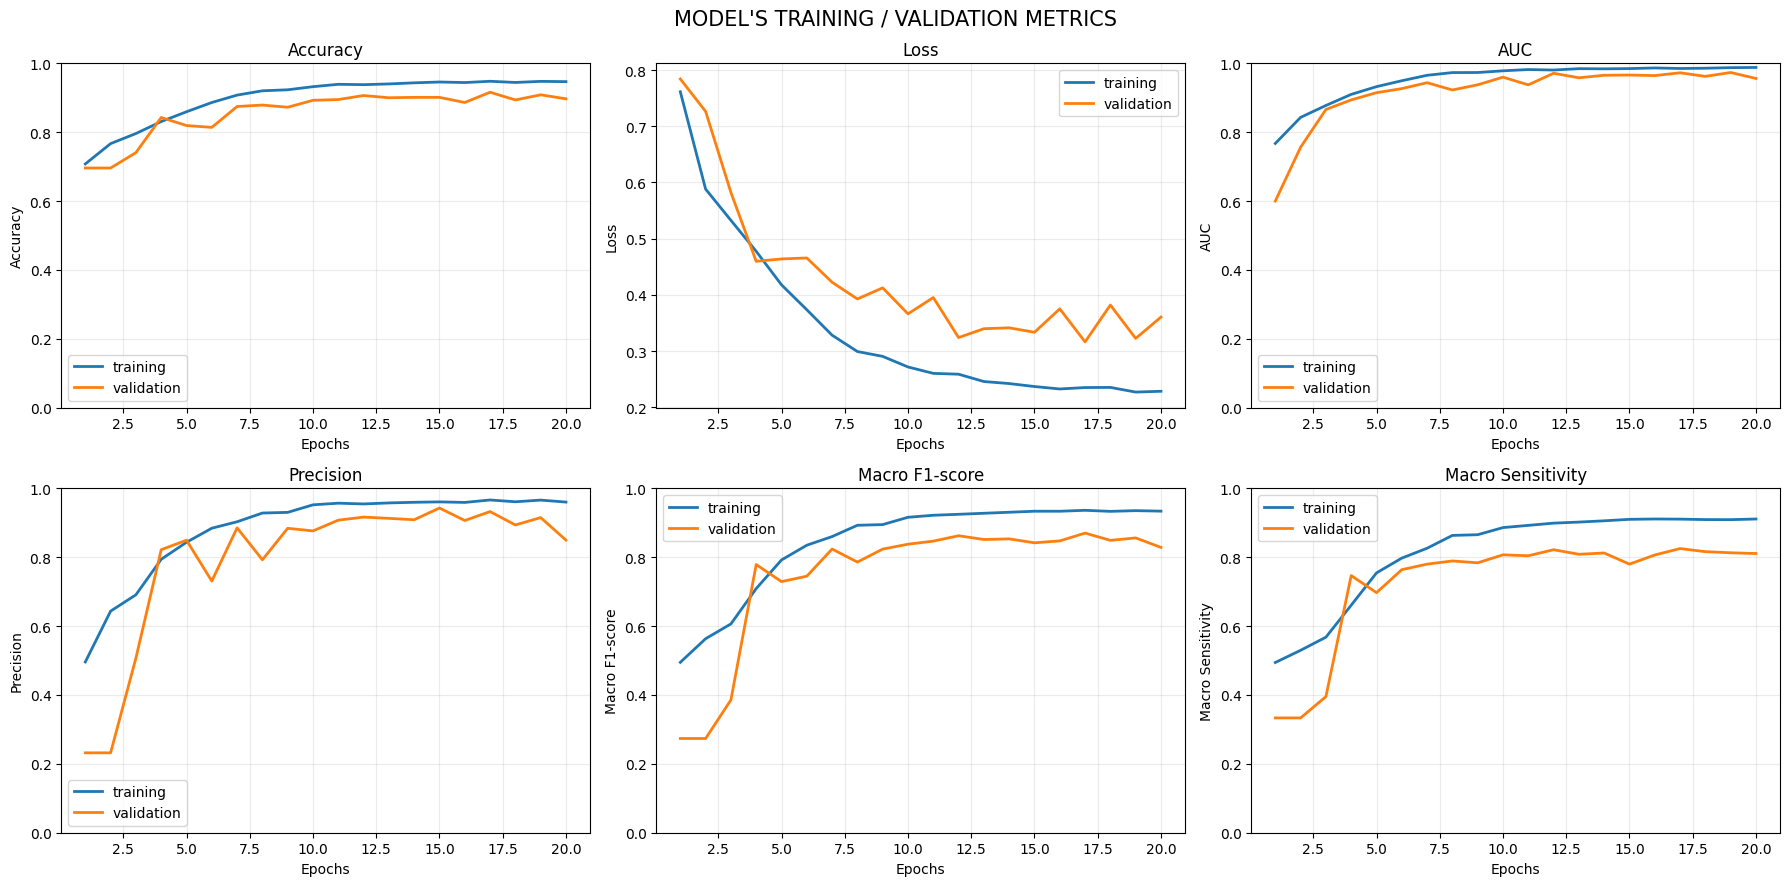

In [31]:
Train_Val_Plot(
    history.history["accuracy"],
    history.history["val_accuracy"],

    history.history["loss"],
    history.history["val_loss"],

    history.history["auc"],
    history.history["val_auc"],

    history.history["precision"],
    history.history["val_precision"],

    history.history["f1_score"],
    history.history["val_f1_score"],

    history.history["sensitivity"],
    history.history["val_sensitivity"]
)


In [32]:
# ============================================================
# 20B. LOAD BEST CHECKPOINT
# ============================================================

import os
import tensorflow as tf
from tensorflow import keras

BEST_MODEL_PATH = best_checkpoint_path

if not os.path.exists(BEST_MODEL_PATH):
    raise FileNotFoundError(
        "Best model checkpoint was not found:\n"
        + BEST_MODEL_PATH
    )

# compile=False is intentional; predictions/evaluation below are
# calculated explicitly using sklearn metrics.
best_model = keras.models.load_model(
    BEST_MODEL_PATH,
    compile=False
)

print("Best model loaded successfully.")
print("Checkpoint:", BEST_MODEL_PATH)


Best model loaded successfully.
Checkpoint: /content/lung_cancer_project/best_proposed_lung_cancer_model.keras


In [33]:
# ============================================================
# 21. VALIDATION PREDICTIONS — THREE-CLASS
#
# No binary threshold is used.
# The predicted class is argmax of the 3-class softmax.
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


def convert_labels_to_class_indices(y_batch):

    y_batch = np.asarray(y_batch)

    if y_batch.ndim == 2:
        return np.argmax(
            y_batch,
            axis=1
        ).astype(np.int32)

    elif y_batch.ndim == 1:
        return y_batch.astype(np.int32)

    else:
        raise ValueError(
            f"Unexpected label shape: {y_batch.shape}"
        )


def predict_generator(model, generator):

    probabilities = []
    labels = []

    for i in range(len(generator)):

        X_batch, y_batch = generator[i]

        predictions = model.predict(
            X_batch,
            verbose=0
        )

        probabilities.extend(
            predictions.tolist()
        )

        batch_labels = convert_labels_to_class_indices(
            y_batch
        )

        labels.extend(
            batch_labels.tolist()
        )

    return (
        np.asarray(labels, dtype=np.int32),
        np.asarray(probabilities, dtype=np.float32)
    )


val_true, val_prob = predict_generator(
    best_model,
    val_gen
)

val_pred = np.argmax(
    val_prob,
    axis=1
)

val_accuracy = accuracy_score(
    val_true,
    val_pred
)

val_precision = precision_score(
    val_true,
    val_pred,
    average="macro",
    zero_division=0
)

val_sensitivity = recall_score(
    val_true,
    val_pred,
    average="macro",
    zero_division=0
)

val_f1 = f1_score(
    val_true,
    val_pred,
    average="macro",
    zero_division=0
)

try:
    val_auc = roc_auc_score(
        tf.keras.utils.to_categorical(
            val_true,
            NUM_CLASSES
        ),
        val_prob,
        multi_class="ovr",
        average="macro"
    )
except ValueError:
    val_auc = float("nan")


print("=" * 70)
print("VALIDATION RESULTS — THREE CLASSES")
print("=" * 70)

print("Validation samples :", len(val_true))
print("Accuracy            :", round(val_accuracy, 4))
print("Macro Precision     :", round(val_precision, 4))
print("Macro Sensitivity   :", round(val_sensitivity, 4))
print("Macro Recall        :", round(val_sensitivity, 4))
print("Macro F1            :", round(val_f1, 4))
print("Macro OVR AUC       :", round(val_auc, 4))

print("\nClassification Report:\n")

print(
    classification_report(
        val_true,
        val_pred,
        labels=[0, 1, 2],
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


VALIDATION RESULTS — THREE CLASSES
Validation samples : 941
Accuracy            : 0.916
Macro Precision     : 0.9325
Macro Sensitivity   : 0.8251
Macro Recall        : 0.8251
Macro F1            : 0.87
Macro OVR AUC       : 0.9739

Classification Report:

                         precision    recall  f1-score   support

         Adenocarcinoma     0.9138    0.9710    0.9415       655
   Large Cell Carcinoma     0.9677    0.6977    0.8108        43
Squamous Cell Carcinoma     0.9159    0.8066    0.8578       243

               accuracy                         0.9160       941
              macro avg     0.9325    0.8251    0.8700       941
           weighted avg     0.9168    0.9160    0.9139       941



In [34]:
# ============================================================
# CELL 21 — DOWNLOAD EXTERNAL CHEST CT DATASET
# ============================================================

!pip install -q kagglehub

import os
import kagglehub

# Download the dataset from:
# https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images

external_path = kagglehub.dataset_download(
    "mohamedhanyyy/chest-ctscan-images"
)

print("Downloaded dataset root:")
print(external_path)

# Locate the folder containing train, valid, and test
possible_data_paths = []

for current_root, directories, files in os.walk(external_path):
    directory_names = {directory.lower() for directory in directories}

    if (
        "train" in directory_names
        and "test" in directory_names
        and ("valid" in directory_names or "validation" in directory_names)
    ):
        possible_data_paths.append(current_root)

if possible_data_paths:
    external_data_root = possible_data_paths[0]
else:
    # Fallback: search for a folder named Data
    data_candidates = []

    for current_root, directories, files in os.walk(external_path):
        for directory in directories:
            if directory.lower() == "data":
                data_candidates.append(os.path.join(current_root, directory))

    if not data_candidates:
        raise FileNotFoundError(
            "Could not locate the Data folder containing train, valid, and test."
        )

    external_data_root = data_candidates[0]

print("\nExternal data root:")
print(external_data_root)

print("\nExternal dataset structure:")
for current_root, directories, files in os.walk(external_data_root):
    level = current_root.replace(external_data_root, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(current_root)}/")

Using Colab cache for faster access to the 'chest-ctscan-images' dataset.
Downloaded dataset root:
/kaggle/input/chest-ctscan-images

External data root:
/kaggle/input/chest-ctscan-images/Data

External dataset structure:
Data/
    valid/
        squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa/
        normal/
        large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa/
        adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib/
    test/
        squamous.cell.carcinoma/
        normal/
        adenocarcinoma/
        large.cell.carcinoma/
    train/
        squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa/
        normal/
        large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa/
        adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib/


In [ ]:

import os
import re

def normalize_name(name):
    return re.sub(
        r"[^a-z0-9]+",
        "",
        str(name).lower()
    )


def find_external_class_directories(root):

    class_dirs = {
        "adenocarcinoma": [],
        "large_cell": [],
        "squamous": []
    }

    for current_root, directories, files in os.walk(root):

        folder_name = normalize_name(
            os.path.basename(current_root)
        )

        if folder_name == "adenocarcinoma":
            class_dirs["adenocarcinoma"].append(
                current_root
            )

        elif folder_name in {
            "largecellcarcinoma",
            "largecell"
        }:
            class_dirs["large_cell"].append(
                current_root
            )

        elif folder_name in {
            "squamouscellcarcinoma",
            "squamouscell",
            "squamous"
        }:
            class_dirs["squamous"].append(
                current_root
            )

    return {
        key: sorted(set(value))
        for key, value in class_dirs.items()
    }


external_class_dirs = find_external_class_directories(
    external_data_root
)

print("=" * 70)
print("EXTERNAL THREE-CLASS DIRECTORIES")
print("=" * 70)

for key, dirs in external_class_dirs.items():

    print(f"\n{key}:")

    for d in dirs:
        print(" ", d)

if any(
    len(v) == 0
    for v in external_class_dirs.values()
):
    raise RuntimeError(
        "Could not find all three required cancer classes "
        "in the external Chest CT dataset."
    )


IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


def collect_external_images(
    directories,
    label,
    class_name
):

    rows = []

    for class_directory in directories:

        for current_root, directories, files in os.walk(
            class_directory
        ):

            for filename in files:

                extension = os.path.splitext(
                    filename
                )[1].lower()

                if extension not in IMAGE_EXTENSIONS:
                    continue

                full_path = os.path.join(
                    current_root,
                    filename
                )

                rows.append({
                    "path": full_path,
                    "label": label,
                    "class_name": class_name,
                    "format": "image",
                    "source": "external_chest_ct"
                })

    return rows


external_pool_rows = []

external_pool_rows.extend(
    collect_external_images(
        external_class_dirs["adenocarcinoma"],
        0,
        "Adenocarcinoma"
    )
)

external_pool_rows.extend(
    collect_external_images(
        external_class_dirs["large_cell"],
        1,
        "Large Cell Carcinoma"
    )
)

external_pool_rows.extend(
    collect_external_images(
        external_class_dirs["squamous"],
        2,
        "Squamous Cell Carcinoma"
    )
)

external_pool_df = (
    pd.DataFrame(external_pool_rows)
    .drop_duplicates(subset=["path"])
    .reset_index(drop=True)
)

if external_pool_df.empty:
    raise RuntimeError(
        "No external cancer images were found."
    )



external_pool_df = (
    external_pool_df
    .sample(frac=1.0, random_state=SEED)
    .reset_index(drop=True)
)

external_test_df, external_unused_df = train_test_split(
    external_pool_df,
    test_size=0.50,
    random_state=SEED,
    shuffle=True,
    stratify=external_pool_df["label"]
)

external_test_df = (
    external_test_df
    .sample(frac=1.0, random_state=SEED)
    .reset_index(drop=True)
)

external_unused_df = (
    external_unused_df
    .sample(frac=1.0, random_state=SEED)
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("EXTERNAL TEST POOL")
print("=" * 70)

print("Complete pooled images :", len(external_pool_df))
print("Final external test    :", len(external_test_df))
print("Unused 50%             :", len(external_unused_df))

print("\nComplete pool class distribution:")
print(external_pool_df["class_name"].value_counts())

print("\nFinal external test distribution:")
print(external_test_df["class_name"].value_counts())

print("\nUnused 50% distribution:")
print(external_unused_df["class_name"].value_counts())


EXTERNAL THREE-CLASS DIRECTORIES

adenocarcinoma:
  /kaggle/input/chest-ctscan-images/Data/test/adenocarcinoma

large_cell:
  /kaggle/input/chest-ctscan-images/Data/test/large.cell.carcinoma

squamous:
  /kaggle/input/chest-ctscan-images/Data/test/squamous.cell.carcinoma

EXTERNAL TEST POOL
Complete pooled images : 261
Final external test    : 130
Unused 50%             : 131

Complete pool class distribution:
class_name
Adenocarcinoma             120
Squamous Cell Carcinoma     90
Large Cell Carcinoma        51
Name: count, dtype: int64

Final external test distribution:
class_name
Adenocarcinoma             60
Squamous Cell Carcinoma    45
Large Cell Carcinoma       25
Name: count, dtype: int64

Unused 50% distribution:
class_name
Adenocarcinoma             60
Squamous Cell Carcinoma    45
Large Cell Carcinoma       26
Name: count, dtype: int64


In [36]:
# ============================================================
# 23. VALIDATE FINAL EXTERNAL TEST FILES
# ============================================================

external_test_df, external_bad_files = (
    validate_dataframe_files(
        external_test_df,
        name="final external test data"
    )
)

print("\nFinal external test size after validation:")
print(len(external_test_df))

for label, class_name in enumerate(CLASS_NAMES):

    print(
        f"{class_name}:",
        int(
            (external_test_df["label"] == label).sum()
        )
    )

print(
    "Corrupt/unreadable files removed:",
    len(external_bad_files)
)



VALIDATING FINAL EXTERNAL TEST DATA
Original files : 130
Valid files    : 130
Corrupt files  : 0

Final external test size after validation:
130
Adenocarcinoma: 60
Large Cell Carcinoma: 25
Squamous Cell Carcinoma: 45
Corrupt/unreadable files removed: 0


In [37]:
# ============================================================
# 24. EXTERNAL TEST GENERATOR
# ============================================================

external_test_gen = MixedImageSequence(
    external_test_df,
    batch_size=BATCH_SIZE,
    shuffle=False,
    augment=False
)

print(
    "External test batches:",
    len(external_test_gen)
)

print(
    "External test images:",
    len(external_test_df)
)


External test batches: 9
External test images: 130


In [38]:
# ============================================================
# 25. EXTERNAL TEST GENERATOR PRE-FLIGHT
# ============================================================

X_test_batch, y_test_batch = (
    external_test_gen[0]
)

print("X shape:", X_test_batch.shape)
print("X dtype:", X_test_batch.dtype)
print("X min:", X_test_batch.min())
print("X max:", X_test_batch.max())

print("y shape:", y_test_batch.shape)
print("y dtype:", y_test_batch.dtype)
print("y values:", np.unique(y_test_batch))

assert X_test_batch.shape[1:] == (
    IMG_SIZE,
    IMG_SIZE,
    3
)

assert np.all(
    np.isin(
        np.argmax(y_test_batch, axis=1),
        [0, 1, 2]
    )
)

print("\nExternal test generator is working correctly.")


X shape: (16, 224, 224, 3)
X dtype: float32
X min: 0.0
X max: 1.0
y shape: (16, 3)
y dtype: float32
y values: [0. 1.]

External test generator is working correctly.



FINAL EXTERNAL TEST RESULTS — THREE CLASSES
Total test images: 130
Adenocarcinoma: 60
Large Cell Carcinoma: 25
Squamous Cell Carcinoma: 45

Accuracy: 0.8846
Macro Precision: 0.9041
Macro Sensitivity: 0.9148
Macro Recall: 0.9148
Macro F1: 0.901
Macro OVR AUC: 0.9847

Classification Report:

                         precision    recall  f1-score   support

         Adenocarcinoma     0.9787    0.7667    0.8598        60
   Large Cell Carcinoma     0.9615    1.0000    0.9804        25
Squamous Cell Carcinoma     0.7719    0.9778    0.8627        45

               accuracy                         0.8846       130
              macro avg     0.9041    0.9148    0.9010       130
           weighted avg     0.9038    0.8846    0.8840       130



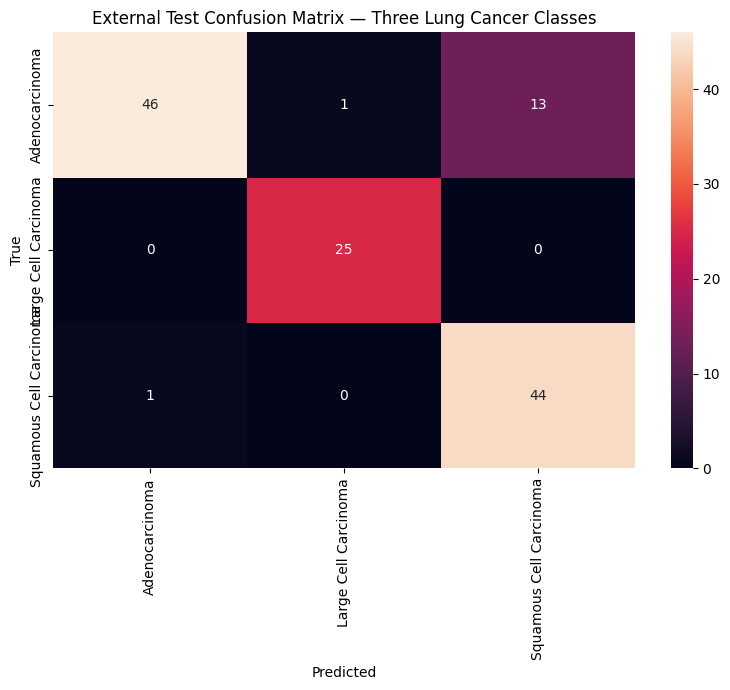


Per-class sensitivity:
Adenocarcinoma: 0.7667
Large Cell Carcinoma: 1.0000
Squamous Cell Carcinoma: 0.9778


In [39]:
# ============================================================
# 26. FINAL EXTERNAL TEST EVALUATION — THREE CLASSES
#
# The external dataset is not used for model fitting or threshold
# selection. Because this is now a 3-class softmax model, prediction
# is simply argmax over the three class probabilities.
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import seaborn as sns
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------

test_true, test_prob = predict_generator(
    best_model,
    external_test_gen
)

test_pred = np.argmax(
    test_prob,
    axis=1
)


# ============================================================
# METRICS
# ============================================================

test_accuracy = accuracy_score(
    test_true,
    test_pred
)

test_precision = precision_score(
    test_true,
    test_pred,
    average="macro",
    zero_division=0
)

# For multiclass classification, macro sensitivity is macro recall:
# mean(TP_c / (TP_c + FN_c)) across the three classes.
test_sensitivity = recall_score(
    test_true,
    test_pred,
    average="macro",
    zero_division=0
)

test_f1 = f1_score(
    test_true,
    test_pred,
    average="macro",
    zero_division=0
)

try:

    test_auc = roc_auc_score(
        tf.keras.utils.to_categorical(
            test_true,
            NUM_CLASSES
        ),
        test_prob,
        multi_class="ovr",
        average="macro"
    )

except ValueError:

    test_auc = float("nan")


print("\n" + "=" * 70)
print("FINAL EXTERNAL TEST RESULTS — THREE CLASSES")
print("=" * 70)

print(
    "Total test images:",
    len(test_true)
)

for label, class_name in enumerate(CLASS_NAMES):

    print(
        f"{class_name}:",
        int(np.sum(test_true == label))
    )

print("\nAccuracy:", round(test_accuracy, 4))
print("Macro Precision:", round(test_precision, 4))
print("Macro Sensitivity:", round(test_sensitivity, 4))
print("Macro Recall:", round(test_sensitivity, 4))
print("Macro F1:", round(test_f1, 4))
print("Macro OVR AUC:", round(test_auc, 4))


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        test_true,
        test_pred,
        labels=[0, 1, 2],
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    test_true,
    test_pred,
    labels=[0, 1, 2]
)

plt.figure(
    figsize=(8, 7)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title(
    "External Test Confusion Matrix — Three Lung Cancer Classes"
)

plt.tight_layout()
plt.show()


# ============================================================
# PER-CLASS SENSITIVITY
# ============================================================

print("\nPer-class sensitivity:")

per_class_sensitivity = recall_score(
    test_true,
    test_pred,
    labels=[0, 1, 2],
    average=None,
    zero_division=0
)

for class_name, sensitivity in zip(
    CLASS_NAMES,
    per_class_sensitivity
):

    print(
        f"{class_name}: {sensitivity:.4f}"
    )


In [ ]:


final_model_path = os.path.join(
    WORK_DIR,
    "lung_cancer_proposed_model_3class_20_epochs.keras"
)

model.save(final_model_path)

metrics_summary = pd.DataFrame([{
    "accuracy": test_accuracy,
    "macro_precision": test_precision,
    "macro_sensitivity": test_sensitivity,
    "macro_recall": test_sensitivity,
    "macro_f1": test_f1,
    "macro_ovr_auc": test_auc,
    "test_samples": len(test_true)
}])

metrics_path = os.path.join(
    WORK_DIR,
    "three_class_external_test_metrics.csv"
)

metrics_summary.to_csv(
    metrics_path,
    index=False
)

print("Final model saved to:")
print(final_model_path)

print("\nMetrics saved to:")
print(metrics_path)


Final model saved to:
/content/lung_cancer_project/lung_cancer_proposed_model_3class_20_epochs.keras

Metrics saved to:
/content/lung_cancer_project/three_class_external_test_metrics.csv
